In [3]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

mv: cannot stat 'kaggle.json': No such file or directory


In [6]:
# !kaggle datasets download -d bhavikjikadara/dog-and-cat-classification-dataset

In [8]:
# !unzip -q dog-and-cat-classification-dataset.zip

In [9]:
import os

base_path = "/content/PetImages"

print(os.listdir(base_path))

['Dog', 'Cat']


In [10]:
!ls

dog-and-cat-classification-dataset.zip	drive  PetImages  sample_data


In [11]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Conv2D,Dense,Flatten,MaxPool2D,Dropout,BatchNormalization
from tensorflow.keras.layers import Activation


In [12]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    base_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(256,256),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    base_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(256,256),
    batch_size=32
)

class_names = train_ds.class_names
print(class_names)

train_ds = train_ds.ignore_errors()
val_ds = val_ds.ignore_errors()


def process(image,label):
    image = tf.cast(image/255., tf.float32)
    return image,label

train_ds = train_ds.map(process)
val_ds = val_ds.map(process)



Found 24998 files belonging to 2 classes.
Using 19999 files for training.
Found 24998 files belonging to 2 classes.
Using 4999 files for validation.
['Cat', 'Dog']


In [13]:
#  AUTOTUNE = tf.data.AUTOTUNE
# train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
# val_ds = val_ds.prefetch(AUTOTUNE)




90% val accuracy

In [41]:

model=Sequential()
model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2),padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2),padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2),padding='valid'))

model.add(Conv2D(256, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2),padding='valid'))



model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(64,activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(1,activation='sigmoid'))



In [43]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])


In [44]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,821,313 (26.02 MB)

 Trainable params: 6,820,353 (26.02 MB)

 Non-trainable params: 960 (3.75 KB)

In [45]:
from keras.callbacks import EarlyStopping
early_stopping=EarlyStopping(monitor='val_accuracy',patience=3,restore_best_weights=True)

In [46]:
history=model.fit(train_ds,validation_data=val_ds,epochs=20,callbacks=[early_stopping])

Epoch 1/20
618/618 ━━━━━━━━━━━━━━━━━━━━ 80s 114ms/step - accuracy: 0.5412 - loss: 1.9683 - val_accuracy: 0.6325 - val_loss: 0.6478
Epoch 2/20
618/618 ━━━━━━━━━━━━━━━━━━━━ 79s 128ms/step - accuracy: 0.6173 - loss: 0.6690 - val_accuracy: 0.5617 - val_loss: 0.7643
Epoch 3/20
618/618 ━━━━━━━━━━━━━━━━━━━━ 65s 105ms/step - accuracy: 0.6978 - loss: 0.5870 - val_accuracy: 0.7019 - val_loss: 0.5699
Epoch 4/20
618/618 ━━━━━━━━━━━━━━━━━━━━ 63s 102ms/step - accuracy: 0.7516 - loss: 0.5095 - val_accuracy: 0.7379 - val_loss: 0.5328
Epoch 5/20
618/618 ━━━━━━━━━━━━━━━━━━━━ 62s 100ms/step - accuracy: 0.7963 - loss: 0.4480 - val_accuracy: 0.8366 - val_loss: 0.3691
Epoch 6/20
618/618 ━━━━━━━━━━━━━━━━━━━━ 80s 129ms/step - accuracy: 0.8533 - loss: 0.3567 - val_accuracy: 0.6727 - val_loss: 0.8080
Epoch 7/20
618/618 ━━━━━━━━━━━━━━━━━━━━ 63s 101ms/step - accuracy: 0.8870 - loss: 0.2779 - val_accuracy: 0.7397 - val_loss: 1.1537
Epoch 8/20
618/618 ━━━━━━━━━━━━━━━━━━━━ 62s 100ms/step - accuracy: 0.9161 - loss: 0

In [47]:
accuracy,loss = model.evaluate(val_ds)

# print("Validation Accuracy:", accuracy)
# print("Validation Loss:", loss)

157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.9047 - loss: 0.2565


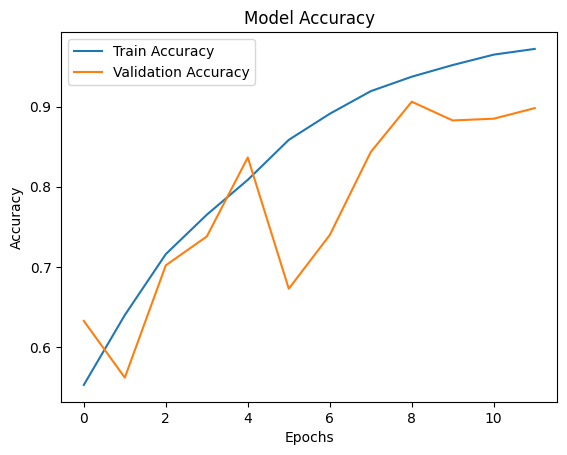

In [48]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.title('Model Accuracy')
plt.show()

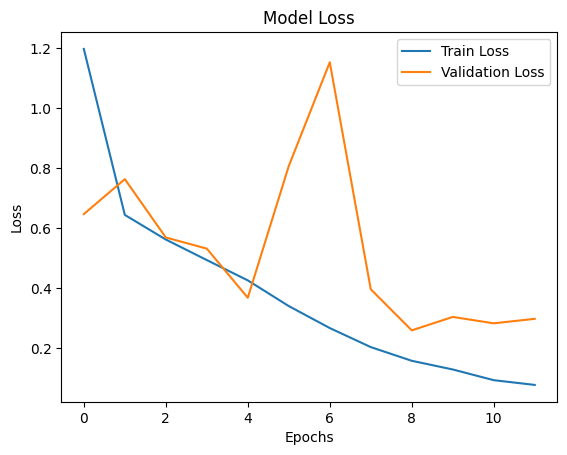

In [49]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train Loss', 'Validation Loss'])
plt.title('Model Loss')
plt.show()

In [50]:
import cv2
import matplotlib.pyplot as plt
import numpy as np



In [51]:
def predict(input):
   img = cv2.imread(input)
   img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
   img = cv2.resize(img, (256,256))
   img = img / 255.0
   img = np.expand_dims(img, axis=0)

   prediction = model.predict(img)[0][0]

   print("Raw output:", prediction)
   print("Predicted:", class_names[int(prediction > 0.5)])

In [56]:
input='/content/dog.jpeg'
predict(input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
Raw output: 0.85923964
Predicted: Dog


In [53]:
# model.save('/content/drive/MyDrive/model.keras')